# Energias renováveis e aprendizado de máquina

O objetivo é comparar três modelos para identificar a fonte de empreendimentos
(Solar, Eólica ou Hidráulica) e três modelos para estimar a radiação solar em Petrolina (PE).

Esta é a avaliação principal em Python. Os resultados usam os dois CSVs fornecidos
com a atividade. O código de consulta às APIs do notebook de apoio foi mantido na seção 2,
mas não é necessário repetir a coleta para executar a análise.

## 1. Importação das bibliotecas

Usamos pandas para trabalhar com as tabelas, matplotlib para os gráficos e
scikit-learn para separar os dados, treinar os modelos e calcular as métricas.

In [1]:
import json
import urllib.parse
import urllib.request
import csv
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

## 2. Origem dos dados e consultas às APIs

Uma API permite pedir dados a um serviço pela internet. O código de apoio faz uma
requisição `GET` e recebe uma resposta JSON, formada por chaves e valores.

**Nesta execução, usamos os CSVs fornecidos, sem uma nova consulta às APIs.**
As funções e os parâmetros abaixo vêm do material de apoio.
A opção `CONSULTAR_APIS = False` evita depender dos serviços para reproduzir os resultados.

Para uma nova coleta, a opção pode ser alterada para `True`. Nesse caso, os arquivos novos
são gravados em `nova_coleta/`, sem substituir os CSVs analisados neste trabalho.
Essa opção depende da disponibilidade das APIs e não foi usada para produzir as saídas entregues.

In [2]:
CONSULTAR_APIS = False

if CONSULTAR_APIS:
    Path('nova_coleta').mkdir(exist_ok=True)

In [3]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

### 2.1. ANEEL / SIGA

Cada linha representa um empreendimento do cadastro. O material de apoio consulta até
1.200 registros por sigla: `UFV` vira Solar; `EOL` vira Eólica; `UHE`, `PCH` e `CGH`
são reunidas em Hidráulica. A data da coleta do CSV fornecido não foi informada.
O cadastro inclui empreendimentos em diferentes fases; não é uma tabela de energia gerada.

In [4]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]

if CONSULTAR_APIS:
    registros_aneel = []
    for sigla in SIGLAS:
        parametros = {
            "resource_id": ID_RECURSO,
            "filters": json.dumps({"SigTipoGeracao": sigla}),
            "limit": 1200,
        }
        resposta = consultar_api(URL_ANEEL, parametros)
        if not resposta.get("success"):
            raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
        linhas = resposta["result"]["records"]
        print(f"{sigla}: {len(linhas)} linhas recebidas")
        registros_aneel.extend(linhas)
    print("Total de linhas recebidas:", len(registros_aneel))

    fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
              "PCH": "Hidráulica", "CGH": "Hidráulica"}
    linhas_classificacao = []
    for registro in registros_aneel:
        potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
        latitude = numero(registro.get("NumCoordNEmpreendimento"))
        longitude = numero(registro.get("NumCoordEEmpreendimento"))
        fonte = fontes.get(registro.get("SigTipoGeracao"))
        if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
            linhas_classificacao.append([potencia, latitude, longitude, fonte])
    if len(linhas_classificacao) < 90:
        raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
    print("Linhas válidas:", len(linhas_classificacao))
    print("Primeiro exemplo:", linhas_classificacao[0])

    with open("nova_coleta/aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
        escritor = csv.writer(arquivo)
        escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
        escritor.writerows(linhas_classificacao)
    print("Salvo: nova_coleta/aneel_classificacao_orange.csv")
else:
    print("ANEEL: usando o CSV fornecido; nova consulta não executada.")

ANEEL: usando o CSV fornecido; nova consulta não executada.


### 2.2. Open-Meteo

Os dados são estimativas históricas de modelos/reanálise para Petrolina (PE),
coordenadas aproximadas -9,39 e -40,50. O período vai de **01/04/2025 a 30/06/2025**,
no fuso `America/Recife`. São mantidos os horários das 7h às 17h.
A radiação corresponde à média da hora anterior, em W/m².

In [5]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}

if CONSULTAR_APIS:
    resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
    if "hourly" not in resposta_meteo:
        raise ValueError("Resposta sem a seção hourly")
    horas_api = resposta_meteo["hourly"]
    print("Campos recebidos:", list(horas_api))
    print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
    print("Quantidade de horários:", len(horas_api["time"]))

    nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
                 "wind_speed_10m", "shortwave_radiation"]
    linhas_regressao = []
    for indice, data_hora in enumerate(horas_api["time"]):
        hora = int(data_hora[11:13])
        valores = [horas_api[nome][indice] for nome in nomes_api]
        if 7 <= hora <= 17 and all(valor is not None for valor in valores):
            linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
    if len(linhas_regressao) < 100:
        raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
    print("Horas válidas:", len(linhas_regressao))
    print("Primeiro exemplo:", linhas_regressao[0])

    with open("nova_coleta/meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
        escritor = csv.writer(arquivo)
        escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                           "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
        escritor.writerows(linhas_regressao)
    print("Salvo: nova_coleta/meteo_regressao_orange.csv")
else:
    print("Open-Meteo: usando o CSV fornecido; nova consulta não executada.")

Open-Meteo: usando o CSV fornecido; nova consulta não executada.


## 3. Classificação da fonte renovável

Na classificação, a resposta é uma categoria. O modelo recebe três informações
e tenta identificar a fonte do empreendimento.

| Coluna | Significado | Uso |
|---|---|---|
| `potencia_kw` | Potência outorgada em kW | Entrada |
| `latitude` | Latitude aproximada, em graus decimais | Entrada |
| `longitude` | Longitude aproximada, em graus decimais | Entrada |
| `fonte` | Solar, Eólica ou Hidráulica | Resposta |

### 3.1. Leitura e análise inicial

In [6]:
aneel_original = pd.read_csv('aneel_classificacao_orange.csv')

print('Quantidade de linhas e colunas:', aneel_original.shape)
display(aneel_original.head())
aneel_original.info()
print('\nValores ausentes por coluna:')
display(aneel_original.isna().sum())

Quantidade de linhas e colunas: (3876, 4)


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB

Valores ausentes por coluna:


potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

### 3.2. Tratamento das linhas repetidas

O CSV tem 3.876 linhas, nenhuma com valor ausente. Há 28 repetições completas além
da primeira ocorrência. Retiramos essas repetições **antes** de separar treino e teste,
para não avaliar o modelo com exemplos idênticos aos usados no treinamento.

A remoção considera as quatro colunas. Como o CSV não possui um identificador do
empreendimento, isso não comprova que cada repetição era um cadastro duplicado.
O arquivo original é preservado; o tratamento ocorre apenas na tabela em memória.

In [7]:
print('Repeticoes completas:', aneel_original.duplicated().sum())

aneel = aneel_original.dropna().drop_duplicates().reset_index(drop=True)

print('Linhas utilizadas na analise:', len(aneel))
print('Linhas com alguma coordenada zero:',
      ((aneel['latitude'] == 0) | (aneel['longitude'] == 0)).sum())
display(aneel.describe().round(2))

Repeticoes completas: 28
Linhas utilizadas na analise: 3848
Linhas com alguma coordenada zero: 27


,potencia_kw,latitude,longitude
count,3848.00,3848.00,3848.00
mean,42140.45,-12.76,-46.40
std,302725.20,9.49,7.69
min,0.16,-33.72,-69.94
25%,419.12,-21.22,-52.58
50%,12460.00,-10.51,-47.49
75%,30000.00,-4.41,-41.32
max,11233100.00,3.83,0.00


,CSV original,Apos retirar repeticoes
fonte,,
Hidráulica,1476,1466
Solar,1200,1195
Eólica,1200,1187


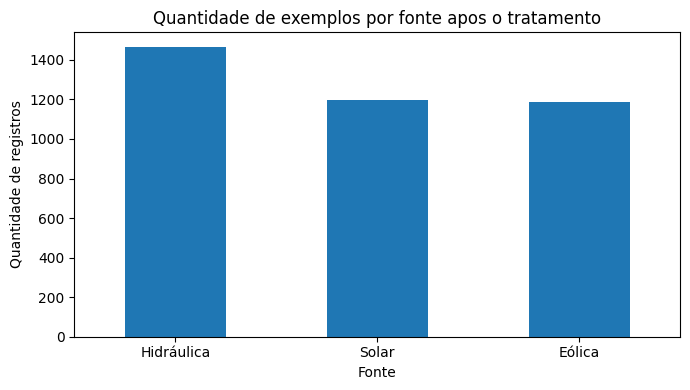

In [8]:
distribuicao = pd.DataFrame({
    'CSV original': aneel_original['fonte'].value_counts(),
    'Apos retirar repeticoes': aneel['fonte'].value_counts()
})
display(distribuicao)

aneel['fonte'].value_counts().plot(kind='bar', figsize=(7, 4), rot=0)
plt.title('Quantidade de exemplos por fonte apos o tratamento')
plt.xlabel('Fonte')
plt.ylabel('Quantidade de registros')
plt.tight_layout()
plt.show()

A análise utiliza **3.848 registros**: 1.466 hidráulicos, 1.195 solares e 1.187 eólicos.
A potência vai de 0,16 a 11.233.100 kW, enquanto as coordenadas usam outra escala.
A mediana da potência é 12.460 kW: alguns valores muito altos elevam a média.

Restaram 27 linhas com latitude ou longitude igual a zero. Não foram corrigidas
por suposição; a qualidade dessas coordenadas é uma limitação do conjunto.
As contagens refletem a amostra consultada, **não a participação das fontes na matriz energética brasileira**.

### 3.3. Entradas, resposta e separação dos dados

`X` contém as informações que o modelo pode usar. `y` contém a resposta que queremos
prever. Não usamos nome, código CEG, sigla da fonte ou qualquer coluna que entregue a resposta.

Separamos aproximadamente 80% para treino e 20% para teste. `stratify=y_classificacao`
mantém proporções semelhantes das classes nos dois grupos. A semente 42 torna a separação
repetível. Os três modelos usam **exatamente a mesma divisão**.

In [9]:
X_classificacao = aneel[['potencia_kw', 'latitude', 'longitude']]
y_classificacao = aneel['fonte']

X_treino_c, X_teste_c, y_treino_c, y_teste_c = train_test_split(
    X_classificacao, y_classificacao,
    test_size=0.20, random_state=42, stratify=y_classificacao
)

print('Treino:', len(X_treino_c), '| Teste:', len(X_teste_c))
display(pd.DataFrame({
    'Treino': y_treino_c.value_counts(),
    'Teste': y_teste_c.value_counts()
}))

Treino: 3078 | Teste: 770


,Treino,Teste
fonte,,
Hidráulica,1173,293
Solar,956,239
Eólica,949,238


### 3.4. Padronização

Padronizar coloca as entradas em escalas comparáveis. Isso é importante para o kNN
e para o ajuste da Regressão Logística. A Random Forest usará os valores originais.

`fit_transform` aprende a média e o desvio **apenas no treino** e transforma esses dados.
No teste, `transform` usa os mesmos valores aprendidos, sem ajustá-los novamente.

In [10]:
padronizador = StandardScaler()
X_treino_padronizado = padronizador.fit_transform(X_treino_c)
X_teste_padronizado = padronizador.transform(X_teste_c)

### 3.5. Treinamento dos três classificadores

**Regressão Logística:** classificador que serve como comparação mais simples. Apesar do
nome, aqui ele prevê categorias. O limite de 1.000 iterações dá tempo para o ajuste terminar.

**kNN:** compara o exemplo com os cinco vizinhos mais próximos e usa a classe mais frequente.
Ajuda a testar se exemplos parecidos em potência e localização têm a mesma fonte.

**Random Forest:** combina 100 árvores de decisão. Permite representar separações mais
complexas entre as classes. As configurações foram fixadas antes da comparação;
não foi feita busca de parâmetros usando o teste.

In [11]:
logistica = LogisticRegression(max_iter=1000, random_state=42)
logistica.fit(X_treino_padronizado, y_treino_c)
previsao_logistica = logistica.predict(X_teste_padronizado)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_treino_padronizado, y_treino_c)
previsao_knn = knn.predict(X_teste_padronizado)

floresta_c = RandomForestClassifier(n_estimators=100, random_state=42)
floresta_c.fit(X_treino_c, y_treino_c)
previsao_floresta_c = floresta_c.predict(X_teste_c)

### 3.6. Comparação dos resultados

**Accuracy** é a proporção total de acertos. **Precision** indica quanto acertamos entre
os exemplos previstos como uma classe. **Recall** indica quanto encontramos entre os exemplos
que realmente pertencem à classe. **F1** combina Precision e Recall.

Precision, Recall e F1 usam a média **macro**: calculamos a métrica em cada classe e damos
o mesmo peso às três. Nessas quatro métricas, valores mais altos são melhores.

In [12]:
previsoes_classificacao = {
    'Regressao Logistica': previsao_logistica,
    'kNN': previsao_knn,
    'Random Forest': previsao_floresta_c
}

resultados_c = []
for nome, previsao in previsoes_classificacao.items():
    resultados_c.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_teste_c, previsao),
        'Precision macro': precision_score(y_teste_c, previsao, average='macro', zero_division=0),
        'Recall macro': recall_score(y_teste_c, previsao, average='macro', zero_division=0),
        'F1 macro': f1_score(y_teste_c, previsao, average='macro', zero_division=0)
    })

tabela_classificacao = pd.DataFrame(resultados_c)
display(tabela_classificacao.round(4))

,Modelo,Accuracy,Precision macro,Recall macro,F1 macro
0,Regressao Logistica,0.8247,0.8268,0.8208,0.8182
1,kNN,0.9675,0.9690,0.9661,0.9673
2,Random Forest,0.9779,0.9787,0.9770,0.9778


### 3.7. Matrizes de confusão

As linhas mostram a classe real e as colunas, a classe prevista.
A diagonal mostra os acertos; os demais valores mostram as confusões.

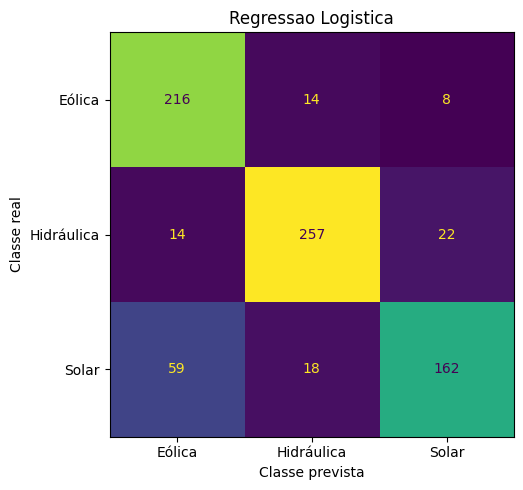

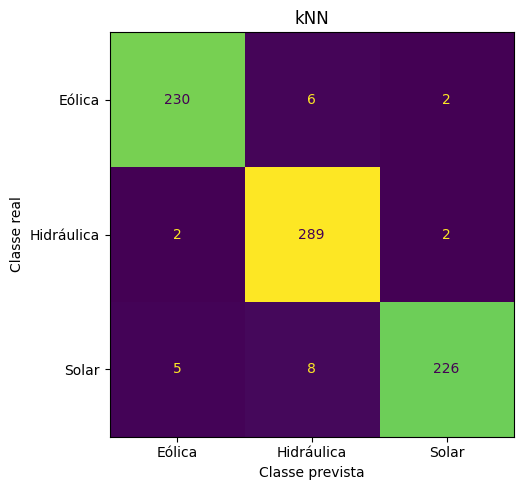

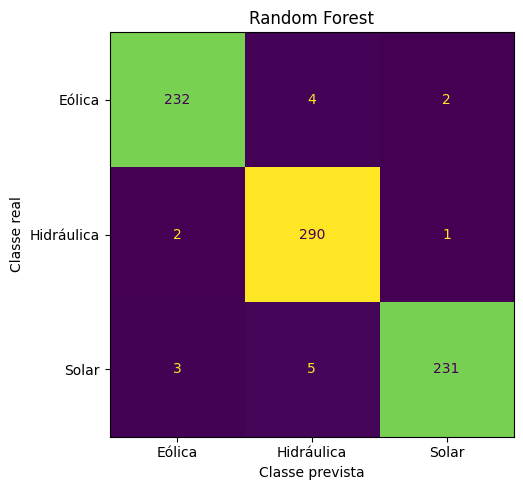

In [13]:
classes = ['Eólica', 'Hidráulica', 'Solar']

for nome, previsao in previsoes_classificacao.items():
    matriz = confusion_matrix(y_teste_c, previsao, labels=classes)
    plt.figure(figsize=(6, 5))
    grafico = ConfusionMatrixDisplay(matriz, display_labels=classes)
    grafico.plot(ax=plt.gca(), colorbar=False, values_format='d')
    plt.title(nome)
    plt.xlabel('Classe prevista')
    plt.ylabel('Classe real')
    plt.tight_layout()
    plt.show()

### 3.8. Interpretação da classificação

A **Random Forest** teve o melhor resultado nesta divisão: **97,79% de acurácia**
e **F1 macro de 0,9778**, com 753 acertos em 770 exemplos de teste.
O kNN ficou próximo, com 96,75% de acurácia. A Regressão Logística ficou em 82,47%.

Na Regressão Logística, a maior confusão foi prever **59 exemplos solares como eólicos**.
No kNN, foram **oito solares previstos como hidráulicos**. Na Random Forest,
a maior confusão foi **cinco solares previstos como hidráulicos**.

Entre os três modelos, escolheríamos a Random Forest com base nessas métricas.
Isso não significa que ela sempre terá o mesmo desempenho em outros dados.
Empreendimentos próximos ou de potência semelhante podem ter fontes diferentes.
O conjunto tem poucas entradas, limite de coleta por sigla e coordenadas que precisam
de cuidado. A divisão aleatória também não testa o desempenho em uma região inteiramente nova.

## 4. Regressão da radiação solar

Na regressão, a resposta é um número. Vamos estimar a radiação a partir das
condições meteorológicas e da hora local.

| Coluna | Significado | Uso |
|---|---|---|
| `data_hora` | Data e hora local | Ordenação; não entra no modelo |
| `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `hora` | Hora local, de 7 a 17 | Entrada |
| `radiacao_w_m2` | Radiação global horizontal média da hora anterior, em W/m² | Resposta |

### 4.1. Leitura e análise inicial

In [14]:
meteo = pd.read_csv('meteo_regressao_orange.csv', parse_dates=['data_hora'])
meteo = meteo.sort_values('data_hora').reset_index(drop=True)

print('Quantidade de linhas e colunas:', meteo.shape)
display(meteo.head())
meteo.info()
print('\nValores ausentes por coluna:')
display(meteo.isna().sum())
print('Horarios repetidos:', meteo['data_hora'].duplicated().sum())
display(meteo.select_dtypes(include='number').describe().round(2))

Quantidade de linhas e colunas: (1001, 7)


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3,74,100,17.7,7,116.0
1,2025-04-01 08:00:00,26.5,66,100,18.1,8,269.0
2,2025-04-01 09:00:00,28.4,55,97,18.0,9,529.0
3,2025-04-01 10:00:00,30.8,44,21,18.4,10,797.0
4,2025-04-01 11:00:00,32.7,36,26,20.1,11,880.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   data_hora      1001 non-null   datetime64[ns]
 1   temperatura_c  1001 non-null   float64       
 2   umidade_pct    1001 non-null   int64         
 3   nuvens_pct     1001 non-null   int64         
 4   vento_kmh      1001 non-null   float64       
 5   hora           1001 non-null   int64         
 6   radiacao_w_m2  1001 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 54.9 KB

Valores ausentes por coluna:


data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64

Horarios repetidos: 0


,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.00,1001.00,1001.00,1001.00,1001.00,1001.00
mean,28.89,50.54,55.11,15.47,12.00,472.85
std,3.66,15.91,37.85,4.92,3.16,256.37
min,19.50,21.00,0.00,2.30,7.00,13.00
25%,26.30,38.00,19.00,12.20,9.00,250.00
50%,29.10,49.00,54.00,15.40,12.00,466.00
75%,31.70,61.00,98.00,19.00,15.00,696.00
max,36.10,95.00,100.00,30.10,17.00,1002.00


São **1.001 observações**, sem valores ausentes ou horários repetidos.
A temperatura varia de 19,5 a 36,1 °C, a umidade de 21% a 95%, as nuvens de 0% a 100%
e o vento de 2,3 a 30,1 km/h. A radiação varia de 13 a 1.002 W/m².
Não foi necessário preencher ou excluir linhas nesta base.

### 4.2. Separação temporal

A radiação é a resposta `y` e **não entra em `X`**, nem por transformação.
Usamos as primeiras 80% das linhas para treino e as últimas 20% para teste.
Não embaralhamos os horários: o modelo aprende com o passado e é avaliado em horas posteriores.

In [15]:
X_regressao = meteo[['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']]
y_regressao = meteo['radiacao_w_m2']

corte = int(len(meteo) * 0.80)
X_treino_r = X_regressao.iloc[:corte]
X_teste_r = X_regressao.iloc[corte:]
y_treino_r = y_regressao.iloc[:corte]
y_teste_r = y_regressao.iloc[corte:]

print('Treino:', len(X_treino_r), '| Teste:', len(X_teste_r))
print('Periodo de treino:', meteo['data_hora'].iloc[0], 'ate', meteo['data_hora'].iloc[corte - 1])
print('Periodo de teste:', meteo['data_hora'].iloc[corte], 'ate', meteo['data_hora'].iloc[-1])

Treino: 800 | Teste: 201
Periodo de treino: 2025-04-01 07:00:00 ate 2025-06-12 14:00:00
Periodo de teste: 2025-06-12 15:00:00 ate 2025-06-30 17:00:00


O treino tem 800 horas e termina em **12/06/2025, às 14h**.
O teste tem 201 horas: de **12/06/2025, às 15h, até 30/06/2025, às 17h**.
O corte fica no meio de um dia porque a regra considera a quantidade de linhas, não dias completos.

### 4.3. Relação entre hora e radiação

O gráfico abaixo usa apenas o treino. Agrupamos os registros por hora para observar
a radiação média em cada horário.

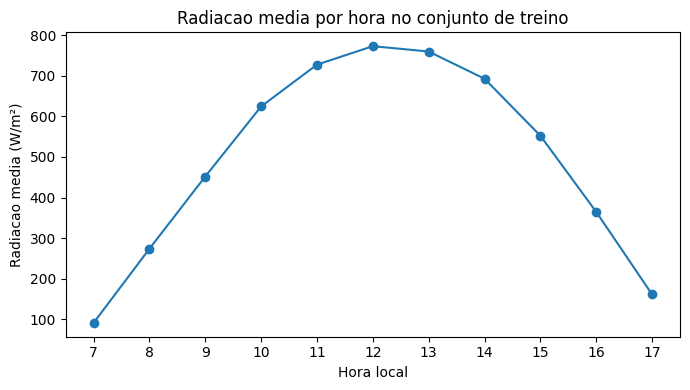

In [16]:
media_por_hora = meteo.iloc[:corte].groupby('hora')['radiacao_w_m2'].mean()
media_por_hora.plot(marker='o', figsize=(7, 4))
plt.title('Radiacao media por hora no conjunto de treino')
plt.xlabel('Hora local')
plt.ylabel('Radiacao media (W/m²)')
plt.xticks(range(7, 18))
plt.tight_layout()
plt.show()

A média aumenta pela manhã, chega ao maior valor às 12h e diminui à tarde.
Por isso, a hora é uma entrada útil. O formato de subida e descida também mostra por que
uma relação apenas linear com a hora pode ser limitada. Esse gráfico é uma observação
dos dados; não mede isoladamente a importância da hora dentro de cada modelo.

### 4.4. Treinamento dos três regressores

**Regressão Linear:** compara os resultados com uma combinação linear das cinco entradas.

**Árvore de Decisão:** divide os dados por regras e permite relações não lineares.

**Random Forest:** usa a média das previsões de 100 árvores, em vez de depender de uma só.

Mantivemos as demais configurações padrão da biblioteca. Não ajustamos parâmetros
para melhorar o resultado no teste. Os três modelos usam as mesmas 800 linhas de treino
e as mesmas 201 linhas de teste.

In [17]:
linear = LinearRegression()
linear.fit(X_treino_r, y_treino_r)
previsao_linear = linear.predict(X_teste_r)

arvore = DecisionTreeRegressor(random_state=42)
arvore.fit(X_treino_r, y_treino_r)
previsao_arvore = arvore.predict(X_teste_r)

floresta_r = RandomForestRegressor(n_estimators=100, random_state=42)
floresta_r.fit(X_treino_r, y_treino_r)
previsao_floresta_r = floresta_r.predict(X_teste_r)

### 4.5. Comparação dos resultados

**MAE** é a média do tamanho dos erros, sem considerar o sinal, em W/m².
**MSE** é a média dos erros ao quadrado, em (W/m²)², e dá mais peso aos erros grandes.
Nos dois casos, menor é melhor.

**R²** compara os erros do modelo com a variação dos valores reais em torno da média
do teste. O valor 1 indica previsão perfeita; 0 corresponde ao erro de usar essa média
como referência; valores negativos são piores que essa referência. R² não é acurácia.

In [18]:
previsoes_regressao = {
    'Regressao Linear': previsao_linear,
    'Arvore de Decisao': previsao_arvore,
    'Random Forest': previsao_floresta_r
}

resultados_r = []
for nome, previsao in previsoes_regressao.items():
    resultados_r.append({
        'Modelo': nome,
        'MAE (W/m²)': mean_absolute_error(y_teste_r, previsao),
        'MSE ((W/m²)²)': mean_squared_error(y_teste_r, previsao),
        'R²': r2_score(y_teste_r, previsao)
    })

tabela_regressao = pd.DataFrame(resultados_r)
display(tabela_regressao.round({'MAE (W/m²)': 2, 'MSE ((W/m²)²)': 2, 'R²': 4}))

,Modelo,MAE (W/m²),MSE ((W/m²)²),R²
0,Regressao Linear,145.20,30034.20,0.3598
1,Arvore de Decisao,88.79,15291.16,0.6741
2,Random Forest,66.80,7307.42,0.8442


### 4.6. Valores reais e previstos

Usamos a Random Forest para visualizar a comparação, pois ela teve o menor MAE.
Pontos sobre a linha tracejada representam previsões iguais aos valores reais.
Quanto mais afastado da linha, maior o erro.

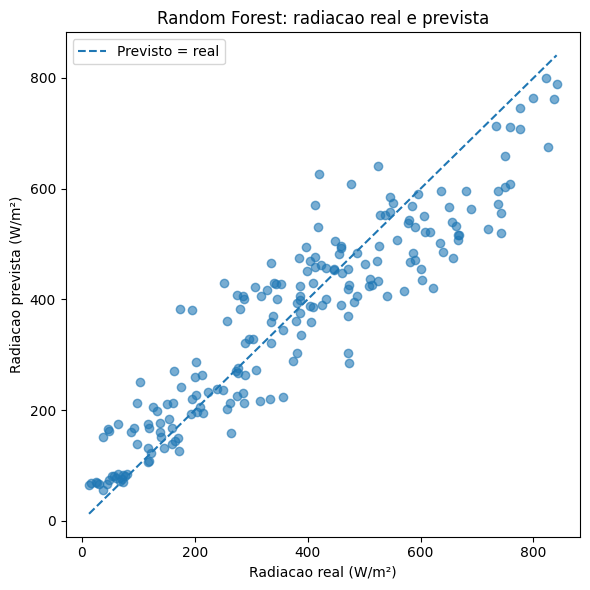

Previsoes negativas da Regressao Linear: 19
Maior erro absoluto da Random Forest (W/m²): 221.76


In [19]:
limite_minimo = min(y_teste_r.min(), previsao_floresta_r.min())
limite_maximo = max(y_teste_r.max(), previsao_floresta_r.max())

plt.figure(figsize=(6, 6))
plt.scatter(y_teste_r, previsao_floresta_r, alpha=0.6)
plt.plot([limite_minimo, limite_maximo], [limite_minimo, limite_maximo],
         linestyle='--', label='Previsto = real')
plt.title('Random Forest: radiacao real e prevista')
plt.xlabel('Radiacao real (W/m²)')
plt.ylabel('Radiacao prevista (W/m²)')
plt.legend()
plt.tight_layout()
plt.show()

print('Previsoes negativas da Regressao Linear:', (previsao_linear < 0).sum())
print('Maior erro absoluto da Random Forest (W/m²):',
      round(abs(y_teste_r - previsao_floresta_r).max(), 2))

### 4.7. Interpretação da regressão

A **Random Forest** teve o menor MAE (**66,80 W/m²**), o menor MSE (**7.307,42 (W/m²)²**)
e o maior R² (**0,8442**). Portanto, foi a melhor dos três nesta divisão.
O MAE não é um limite para cada erro: o maior erro absoluto da floresta foi **221,76 W/m²**.

A Árvore de Decisão ficou em segundo, com MAE de **88,79 W/m²**.
A Regressão Linear teve MAE de **145,20 W/m²** e produziu **19 previsões negativas**,
que não fazem sentido como radiação solar recebida. Elas não foram cortadas ou alteradas
antes do cálculo das métricas. Os resultados sugerem que os modelos com relações não lineares
representaram melhor este conjunto.

**Radiação não é geração elétrica.** O alvo informa radiação por área, em W/m².
O CSV não informa a área de painéis, sua eficiência ou as perdas de uma instalação.
Por isso, esse resultado não fornece diretamente a energia elétrica produzida em kWh.

A avaliação se limita a Petrolina, ao período estudado e aos horários diurnos.
Usamos condições meteorológicas da própria observação; isso não demonstra capacidade
de prever a radiação de um dia futuro sem conhecer essas entradas.

## 5. Conclusão

Foram comparados três classificadores e três regressores, sempre com a mesma divisão
de dados dentro de cada tarefa. Na classificação, a Random Forest teve o melhor resultado
para identificar a fonte. Na regressão, também apresentou os menores erros.

Os resultados respondem às duas perguntas da avaliação com os dados fornecidos,
mas não eliminam as limitações da amostra. Mais acertos no teste não garantem
o mesmo desempenho em outras regiões ou períodos.

## Referências

Base da atividade: `README.md` e `Aula_APIs_Energia_Renovavel_ML.ipynb` fornecidos pelo professor.
As consultas e o agrupamento das fontes foram adaptados desse notebook de apoio.

- [ANEEL / SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel).
- [Open-Meteo: API histórica e unidades](https://open-meteo.com/en/docs/historical-weather-api).
- [scikit-learn: separação entre treino e teste](https://scikit-learn.org/1.8/modules/generated/sklearn.model_selection.train_test_split.html).
- [scikit-learn: cuidados com a preparação dos dados](https://scikit-learn.org/1.8/common_pitfalls.html).
- [scikit-learn: métricas de avaliação](https://scikit-learn.org/1.8/modules/model_evaluation.html).